In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from datetime import datetime
from dataclasses import dataclass
from tqdm import tqdm
import seaborn as sns

# Data parsing

In [2]:
@dataclass
class RouteData:
    timestamp: datetime
    car_id: str
    car_type: str
    gate_name: str

data: list[RouteData] = []

with open('../data/sensors.csv', 'r') as file:
    lines = file.readlines()[1:]

    for line in tqdm(lines):
        timestamp, car_id, car_type, gate_name = line.strip().split(',')

        timestamp = datetime.strptime(timestamp, '%Y-%m-%d %H:%M:%S')

        data.append(RouteData(timestamp, car_id, car_type, gate_name))

data = sorted(data, key=lambda x: x.timestamp)

100%|██████████| 171477/171477 [00:01<00:00, 163343.96it/s]


# Grouping by `car_id`

In [3]:
routes = {}

for point in tqdm(data):
    if point.car_id not in routes:
        routes[point.car_id] = []
    
    routes[point.car_id].append(point)

  0%|          | 0/171477 [00:00<?, ?it/s]

100%|██████████| 171477/171477 [00:00<00:00, 2174631.25it/s]


# Route points distribution

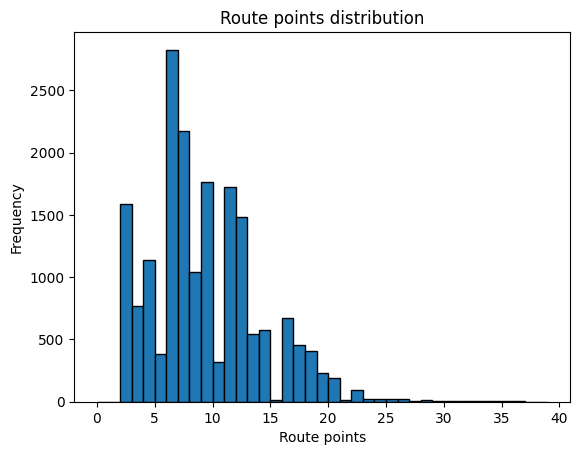

In [4]:
route_lengths = [len(route) for route in routes.values()]

plt.hist(route_lengths, bins=range(40), edgecolor='black')
plt.title('Route points distribution')
plt.xlabel('Route points')
plt.ylabel('Frequency')
plt.show()

# No camping routes stats

In [5]:
routes_no_camping = {car_id: route for car_id, route in routes.items() if not any(point.gate_name.startswith('camping') for point in route)}

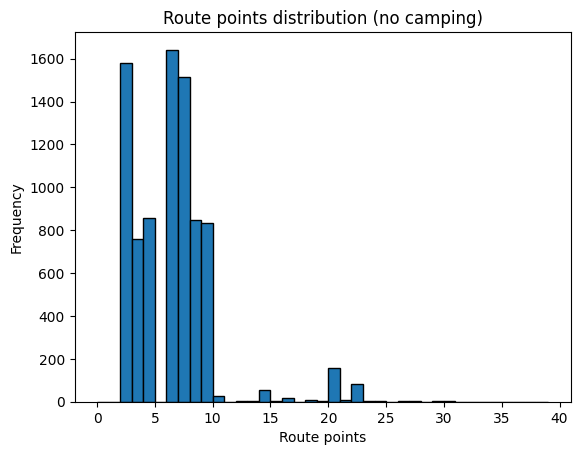

In [6]:
plt.hist([len(route) for route in routes_no_camping.values()], bins=range(40), edgecolor='black')
plt.title('Route points distribution (no camping)')
plt.xlabel('Route points')
plt.ylabel('Frequency')
plt.show()

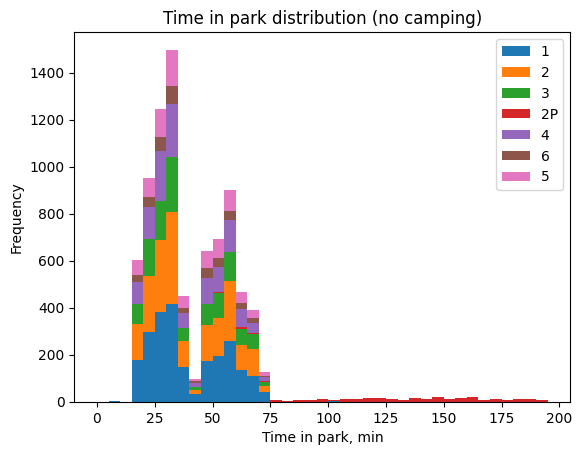

In [7]:
car_types = set(x.car_type for x in data)
hist_data = [[(route[-1].timestamp - route[0].timestamp).seconds / 60 for route in routes_no_camping.values() if route[0].car_type == car_type] for car_type in car_types]

plt.hist(hist_data, stacked=True, bins=range(0, 200, 5), label=list(car_types))
plt.title('Time in park distribution (no camping)')
plt.xlabel('Time in park, min')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Activity

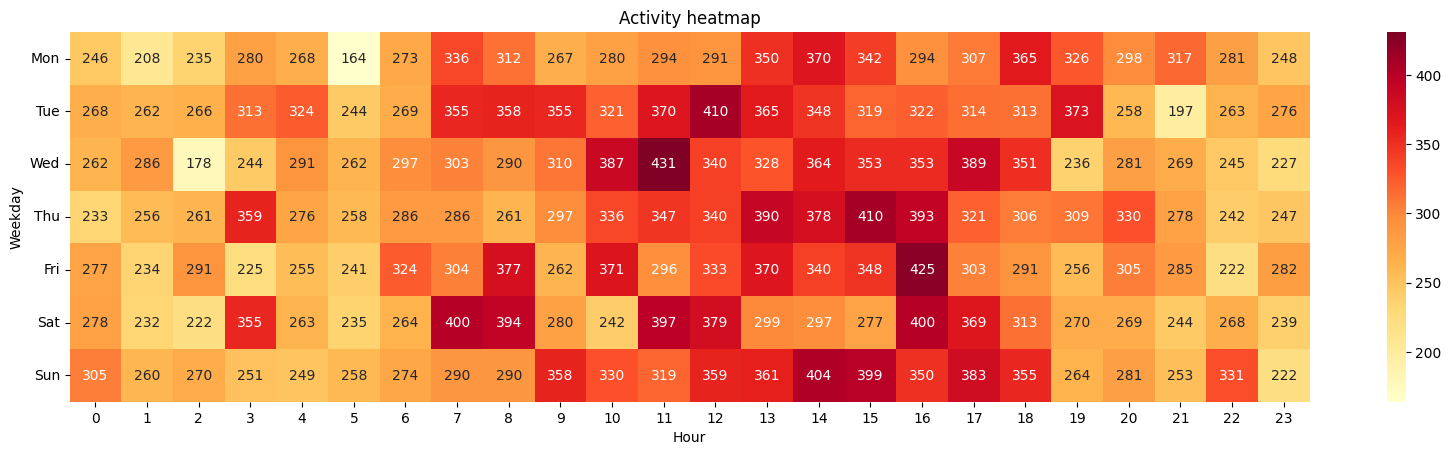

In [8]:
heatmap_data = np.zeros((7, 24), np.int32)

for route in routes_no_camping.values():
    for point in route:
        timestamp = point.timestamp
        heatmap_data[timestamp.weekday(), timestamp.hour] += 1
    
plt.figure().set_figwidth(20)
ax = plt.subplot()
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', annot=True, fmt='d')
ax.set_title('Activity heatmap')
ax.set_xlabel('Hour')
ax.set_ylabel('Weekday')
ax.set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
ax.set_xticks(np.arange(24) + 0.5)
_ = ax.set_xticklabels(range(24), rotation=0)

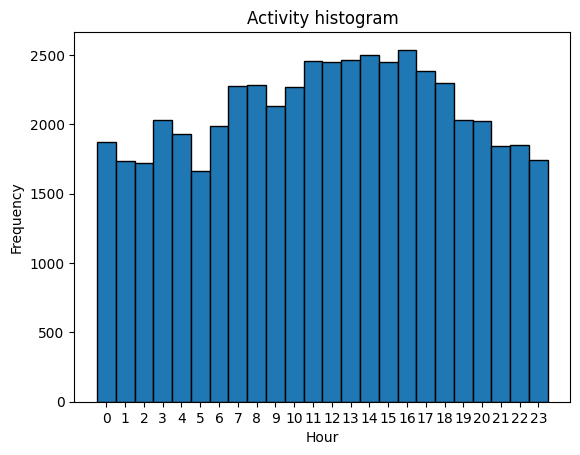

In [9]:
plt.bar(np.arange(24), heatmap_data.sum(axis=0), 1, edgecolor='black', align='center')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Activity histogram')
plt.xticks(np.arange(24))
plt.show()

# Routes

In [10]:
max(len(route) for route in routes_no_camping.values() if route[0].car_type != '2P')

14

In [16]:
edges = [[(start.gate_name, end.gate_name) for start, end in zip(route, route[1:])] for route in routes_no_camping.values() if route[0].car_type != '2P']
max_layer = max(len(route) for route in routes_no_camping.values())

layers = [{'nodes': [], 'sources': [], 'targets': [], 'values': []} for _ in range(max_layer)]
for n_layer, layer in tqdm(enumerate(layers[:-1])):
    layer_edges = [route[n_layer] for route in edges if len(route) > n_layer]
    for (start, end) in layer_edges:
        # ensure start index
        if start not in layer['nodes']:
            layer['nodes'].append(start)
            start_idx = len(layer['nodes']) - 1
        else:
            start_idx = layer['nodes'].index(start)
        
        # ensure end index
        if end not in layers[n_layer + 1]['nodes']:
            layers[n_layer + 1]['nodes'].append(end)
            end_idx = len(layers[n_layer + 1]['nodes']) - 1
        else:
            end_idx = layers[n_layer + 1]['nodes'].index(end)
        
        # update value
        for i, _ in enumerate(layer['sources']):
            if layer['sources'][i] == start_idx and layer['targets'][i] == end_idx:
                layer['values'][i] += 1
                break
        else:
            layer['sources'].append(start_idx)
            layer['targets'].append(end_idx)
            layer['values'].append(1)

nodes = []
sources = []
targets = []
values = [] 

for n_layer, layer in enumerate(layers):
    layer_idx_base = len(nodes)
    nodes.extend(layer['nodes'])
    sources.extend(idx + layer_idx_base for idx in layer['sources'])
    values.extend(layer['values'])

    if n_layer > 0:
        targets.extend(idx + layer_idx_base for idx in layers[n_layer - 1]['targets'])

def node_to_color(node: str, alpha=1.0) -> str:
    SENSOR_COLOR = {
        'entrance': (46, 204, 113),
        'general-gate': (52, 152, 219),
        'gate': (231, 76, 60),
        'ranger-stop': (243, 156, 18),
        'camping': (155, 89, 182),
    }

    for prefix, (r, g, b) in SENSOR_COLOR.items():
        if node.startswith(prefix):
            return f'rgba({r},{g},{b},{alpha})'
    
    return 'rgba(255,0,0,1)'

node_colors = [node_to_color(node) for node in nodes]
link_colors = [node_to_color(nodes[idx], alpha=0.4) for idx in sources]

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node = dict(label = nodes, color=node_colors),
    link = dict(source = sources, target = targets, value = values, color=link_colors)
))
fig.update_layout(title = 'Routes flow')
fig.show()

29it [00:00, 516.94it/s]
